# Finite Group Representations and FFT on Cyclic Groups

On the cyclic group $\mathbb Z_n$, irreducible characters are
$$
\chi_k(t)=e^{-2\pi i kt/n}.
$$
The DFT diagonalizes circular convolution, which is the group algebra product.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/finite-groups-fft-cyclic/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/finite-groups-fft-cyclic") if Path("python/finite-groups-fft-cyclic").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Finite Group Representations and FFT on Cyclic Groups**, with equations and plots designed to expose both the model and the numerical behavior.


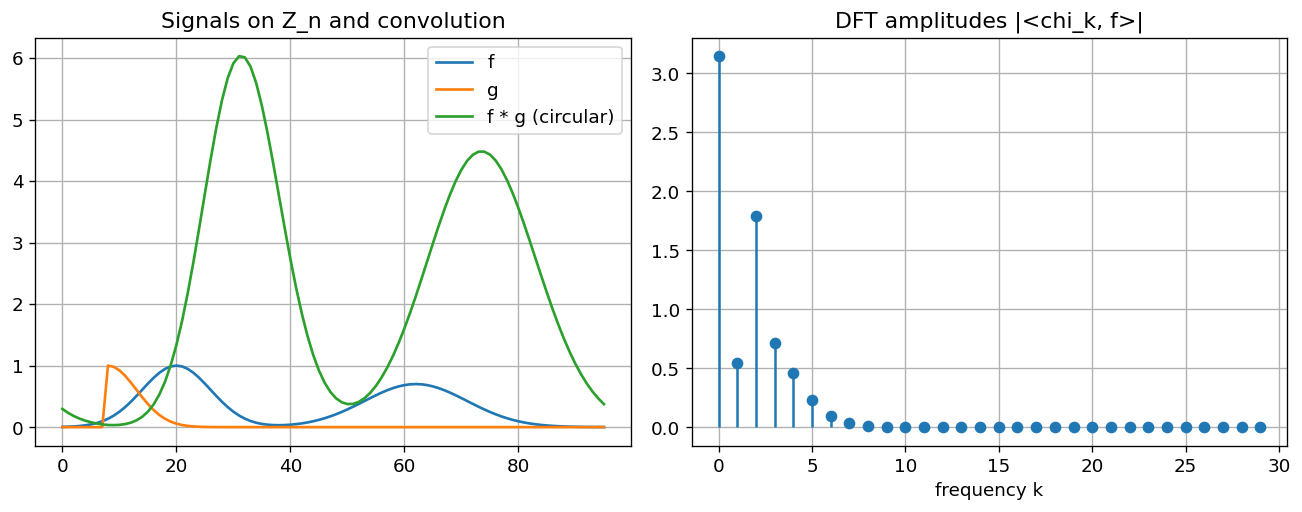

In [2]:
n = 96
t = np.arange(n)
f = np.exp(-0.5*((t-20)/6)**2) + 0.7*np.exp(-0.5*((t-62)/9)**2)
g = np.exp(-0.5*((t-0)/5)**2)
g = np.roll(g, 8)

conv_time = np.fft.ifft(np.fft.fft(f) * np.fft.fft(g)).real

k = np.arange(n)
Chi = np.exp(-2j*np.pi*np.outer(k, t)/n) / np.sqrt(n)
F = Chi @ f

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(f, lw=1.6, label="f")
axes[0].plot(g, lw=1.6, label="g")
axes[0].plot(conv_time, lw=1.6, label="f * g (circular)")
axes[0].set_title("Signals on Z_n and convolution")
axes[0].legend()

axes[1].stem(np.arange(30), np.abs(F[:30]), basefmt=" ")
axes[1].set_title("DFT amplitudes |<chi_k, f>|")
axes[1].set_xlabel("frequency k")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


### References

- T. W. Körner, *Fourier Analysis*.
- P. Diaconis, *Group Representations in Probability and Statistics*.
